# 02_分类算法-C4.5

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 保留增益率决策树教学实现；树图使用 Matplotlib 内联绘制，不需要系统 Graphviz。此简化实现使用预剪枝，不实现完整 C4.5 的缺失值分配及后剪枝。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天要聊的是决策树的另外一种算法：C4.5。

C4.5 用于数据分类（也就是把数据分成不同的类别）。如果你学过 ID3 算法，C4.5 其实是它的升级版，解决了一些 ID3 的问题，比如处理**缺失值**和**连续数值**。

比如在帮朋友选购手机，你会问一些问题：

- **预算是多少？**
- **更喜欢 iPhone 还是安卓？**
- **主要用来打游戏还是拍照？**

根据朋友的回答，你一步步缩小选择范围，最终推荐最合适的手机。这就是 C4.5 的工作方式——**它建立一棵“决策树”，根据数据的不同特征，一步步分类，直到得出最终的结论**。

**C4.5 主要特点**：

1. **可以处理连续数值**（比如“价格 3000 元”而不是“高/中/低”）。
2. **能处理缺失值**（比如有些人没提供“是否打游戏”这个信息）。
3. **使用信息增益率**（相比 ID3，更平衡地选择决策分支）。
4. **生成的决策树可以进行剪枝**（避免树太复杂，防止过拟合）。

C4.5 就像一个高效的筛选系统，通过一个一个条件筛选数据，最终做出决策，被广泛用于机器学习和数据挖掘领域。

## 理论基础

C4.5 的核心思想是：**基于信息增益率（Gain Ratio）选择最优特征进行划分，最终形成一棵决策树**。

### 1. 信息论基础

C4.5 依赖于信息论来衡量数据集的不确定性和特征的分类能力，关键数学概念包括**熵（Entropy）、信息增益（Information Gain）和信息增益率（Gain Ratio）**。

#### 熵（Entropy）

熵衡量数据的不确定性（或纯度），定义为：


$$
H(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$


其中：

$S$是当前数据集，

$c$是类别数，

$p_i$是第 $i$个类别的概率（即该类别样本数量占总样本数量的比例）。

**注意**：

- 如果所有样本都属于同一类，熵为 0（完全纯净）。
- 如果样本均匀分布到所有类别，熵最大（最不确定）。

#### 条件熵（Conditional Entropy）

假设数据集 $S$按照某个特征 $A$划分成 $v$个子集 $S_1, S_2, ..., S_v$，则条件熵定义为：


$$
H(S|A) = \sum_{j=1}^{v} \frac{|S_j|}{|S|} H(S_j)
$$


其中：

- $|S_j|$是第 $j$个子集的大小，
- $|S|$是原数据集大小，
- $H(S_j)$是子集 $S_j$的熵。

熵衡量了按某个特征划分数据后，数据的平均不确定性。

#### 信息增益（Information Gain）

信息增益衡量特征 $A$带来的不确定性减少量，定义为：


$$
IG(A) = H(S) - H(S|A)
$$


选择信息增益最大的特征进行划分，意味着该特征最能降低不确定性。

### 2. C4.5 的核心改进

ID3 选择**信息增益**最大的特征进行划分，但 ID3 有个缺陷：**它偏向于选择取值较多的特征（即特征的值越多，信息增益通常越大）**。为了解决这个问题，C4.5 引入**信息增益率（Gain Ratio）**。

#### 信息增益率（Gain Ratio）

信息增益率引入了一个新的度量 **“固有值（Split Information）”** 来惩罚取值较多的特征：


$$
SI(A) = - \sum_{j=1}^{v} \frac{|S_j|}{|S|} \log_2 \frac{|S_j|}{|S|}
$$


$SI(A)$越大，说明特征 $A$取值越多，划分越细。

- **类似于熵，衡量特征本身的分布情况**。

最终，信息增益率定义为：


$$
GR(A) = \frac{IG(A)}{SI(A)}
$$


- **信息增益率综合考虑信息增益和固有值，避免 ID3 过度倾向于多值特征的问题**。
- C4.5 选择**信息增益率最大**的特征进行划分，而不是仅仅依赖信息增益。

### 3. 处理连续值的特征

C4.5 能够处理连续型数据，而 ID3 只能处理离散型数据。

方法如下：

1. **排序所有样本在该特征上的值**，设这些值为 $v_1, v_2, ..., v_n$。
2. **计算所有相邻样本值的中点作为候选划分点**：


$$
T_i = \frac{v_i + v_{i+1}}{2}, \quad i = 1, 2, ..., n-1
$$


1. **对于每个候选划分点**，将数据集划分为**小于等于** $T_i$**和大于** $T_i$**的两部分**，计算信息增益率，选择最优划分点。

### 4. 处理缺失值

C4.5 允许数据集中某些特征值缺失，处理方式：

1. **计算特征的权重**：假设某个特征 $A$在某些样本上缺失，用该特征在其他样本的**出现比例**来调整计算信息增益率。
2. **在决策过程中处理缺失值**：当一个样本在决策时遇到缺失的特征值，不是简单跳过，而是**按照该特征的已知值的分布概率分配样本**。

### 5. 决策树的剪枝

C4.5 使用**后剪枝（Post-Pruning）**策略来降低过拟合风险：

1. **计算叶节点的分类错误率**：设叶节点包含 $n$个样本，其中 $k$个分类错误，则错误率：  
$e = \frac{k}{n}$
2. **计算子树的分类错误率**，并与未剪枝的树进行比较：若剪枝后错误率降低，则进行剪枝。

**剪枝的目的是降低模型复杂度，提高泛化能力**。

### 6. C4.5 算法流程

1. **计算数据集的总熵**。
2. **计算每个特征的信息增益和信息增益率**。
3. **选择信息增益率最高的特征作为划分点**：

   - 若特征是离散值，按照该特征的不同取值划分子集；
   - 若特征是连续值，找到最优的划分点。
4. **递归构建子树**：

   - 若子集仍然需要进一步划分，重复上述步骤；
   - 若子集已达到纯净（熵为 0），则停止划分。
5. **处理缺失值**：

   - 在计算信息增益率时，调整样本权重；
   - 在分类时，按概率分配缺失值样本。
6. **剪枝**：

   - 计算叶节点的错误率；
   - 若剪枝能降低错误率，则剪枝。

总结来看，C4.5 相比 ID3 主要有三个核心改进：

1. **使用信息增益率**（解决 ID3 偏向多值特征的问题）。
2. **处理连续数值特征**（通过选取最优划分点）。
3. **能处理缺失值**（通过概率分配和调整计算）。

C4.5 是后续**随机森林 和 XGBoost 等算法的基础**。

## Python案例

下面给出一个使用 Python 实现 C4.5 算法的完整示例。

例子中我们将使用 Iris 数据集（实际问题中也可以用其他数据）：

1. 实现基于信息增益率的决策树（包括处理连续属性）；
2. 对决策树进行剪枝优化（采用预剪枝策略）；
3. 对训练结果进行分析和可视化（利用 graphviz 展示树结构）。

Test Accuracy: 100.00%


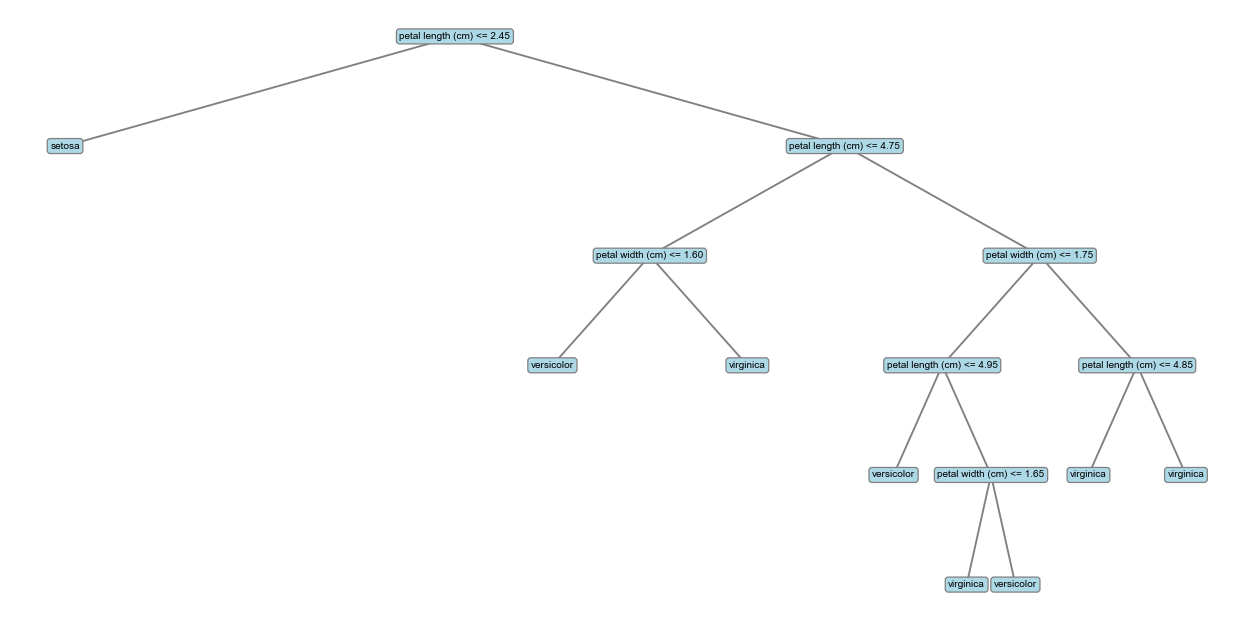

In [2]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. 辅助函数：计算熵、信息增益、固有值、信息增益率
def entropy(y):
    """计算熵：H(S) = - Σ (p * log2(p))"""
    counts = Counter(y)
    total = len(y)
    ent = 0.0
    for count in counts.values():
        p = count / total
        ent -= p * np.log2(p + 1e-9)
    return ent

def split_dataset(X, y, feature_index, threshold):
    """
    对连续型特征按照阈值进行划分，返回左右子集：
    left: 特征值 <= threshold; right: 特征值 > threshold
    """
    mask = X[:, feature_index] <= threshold
    return X[mask], y[mask], X[~mask], y[~mask]

def info_gain_ratio(X, y, feature_index, threshold):
    """
    计算给定特征与阈值的分裂的信息增益率：
    1. 计算划分前的熵 H(S)
    2. 按阈值划分，计算条件熵 H(S|A)
    3. 计算信息增益 IG = H(S) - H(S|A)
    4. 计算固有值 SI
    5. 返回增益率 GR = IG / SI
    """
    # 1. 总熵
    H = entropy(y)
    # 划分数据集
    X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)
    n = len(y)
    n_left, n_right = len(y_left), len(y_right)
    if n_left == 0 or n_right == 0:
        # 如果某一边为空，则无法划分，返回增益率为0
        return 0, None, None, None
    # 2. 条件熵
    H_cond = (n_left /n) * entropy(y_left) + (n_right /n) * entropy(y_right)
    # 3. 信息增益
    ig = H - H_cond
    # 4. 固有值
    si = - (n_left /n) * np.log2(n_left /n + 1e-9) - (n_right /n) * np.log2(n_right /n + 1e-9)
    # 5. 增益率（防止 si 为 0）
    gr = ig / si if si > 1e-9 else 0
    return gr, ig, threshold, (X_left, y_left, X_right, y_right)

# 2. 定义决策树结构（C4.5 树）
class TreeNode:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
        """
        如果是叶节点，则 value 不为 None，表示预测的类别；
        如果是非叶节点，则记录划分的特征索引和阈值，并链接左右子树。
        """
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # 叶节点类别

def majority_class(y):
    """返回 y 中出现最多的类别"""
    return Counter(y).most_common(1)[0][0]

# 3. 构建 C4.5 决策树（递归生成树结构）
def build_tree(X, y, feature_indices, min_samples_split=10, max_depth=10, depth=0):
    """
    参数：
        X: 特征矩阵
        y: 标签
        feature_indices: 待选特征下标（本例中所有特征均可用）
        min_samples_split: 如果样本数小于该值则停止划分（预剪枝策略）
        max_depth: 树最大深度
        depth: 当前递归深度
    返回：
        TreeNode 对象（决策树节点）
    """
    # 如果样本完全属于同一类别或满足停止条件
    if len(set(y)) == 1 or len(y) < min_samples_split or depth >= max_depth:
        return TreeNode(value=majority_class(y))

    best_feature = None
    best_threshold = None
    best_gain_ratio = -1
    best_split = None

    # 遍历每个特征，寻找最优分裂（对于连续值特征，遍历所有候选阈值）
    for feature_index in feature_indices:
        feature_values = X[:, feature_index]
        # 获取排序后的唯一值作为候选划分点（采用相邻中点法）
        sorted_vals = np.sort(np.unique(feature_values))
        if len(sorted_vals) == 1:
            continue
        candidate_thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0
        for threshold in candidate_thresholds:
            gr, ig, th, split = info_gain_ratio(X, y, feature_index, threshold)
            if gr > best_gain_ratio:
                best_gain_ratio = gr
                best_feature = feature_index
                best_threshold = threshold
                best_split = split

    # 如果没有有效划分，则返回叶节点
    if best_gain_ratio <= 0 or best_split is None:
        return TreeNode(value=majority_class(y))

    # 分裂数据集
    X_left, y_left, X_right, y_right = best_split
    # 递归构造左右子树
    left_subtree = build_tree(X_left, y_left, feature_indices, min_samples_split, max_depth, depth +1)
    right_subtree = build_tree(X_right, y_right, feature_indices, min_samples_split, max_depth, depth +1)

    return TreeNode(feature_index=best_feature, threshold=best_threshold,
                    left=left_subtree, right=right_subtree)

# 4. 预测函数

def predict_sample(node, sample):
    """对单一样本递归预测类别"""
    if node.value is not None:
        return node.value
    if sample[node.feature_index] <= node.threshold:
        return predict_sample(node.left, sample)
    else:
        return predict_sample(node.right, sample)

def predict(tree, X):
    """对样本矩阵 X 进行预测"""
    return np.array([predict_sample(tree, sample) for sample in X])

# 5. 可视化决策树

def visualize_tree(node, feature_names, class_names):
    fig, ax = plt.subplots(figsize=(14, 7))
    def draw(current, x, y, dx):
        if current.value is not None:
            label = str(class_names[current.value])
        else:
            label = f"{feature_names[current.feature_index]} <= {current.threshold:.2f}"
        ax.text(x, y, label, ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='gray'))
        if current.value is None:
            for child, sign in [(current.left, -1), (current.right, 1)]:
                nx, ny = x + sign * dx, y - 1
                ax.plot([x, nx], [y, ny], color='gray')
                draw(child, nx, ny, dx / 2)
    draw(node, 0, 0, 4)
    ax.axis('off'); plt.tight_layout(); plt.show()

# 6. 案例演示：使用 Iris 数据集
if __name__ == "__main__":
    # 加载数据集
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    class_names = iris.target_names

    # 划分训练集和测试集（例如 70%/30%）
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 构造 C4.5 决策树
    # 使用预剪枝参数：最小样本数 5，最大深度 5（实际可调）
    tree = build_tree(X_train, y_train, feature_indices=list(range(X.shape[1])),
                      min_samples_split=5, max_depth=5)

    # 对测试集进行预测，并计算准确率
    y_pred = predict(tree, X_test)
    accuracy = np.mean(y_pred == y_test)
    print("Test Accuracy: {:.2f}%".format(accuracy * 100))

    # 7. 可视化决策树
    visualize_tree(tree, feature_names, class_names)

1. **算法原理与分裂选择**：代码通过计算熵、条件熵及信息增益率来确定最佳划分点。对于连续特征，采用候选阈值（相邻数值中点）进行遍历，并选择信息增益率最大的作为划分依据。这样避免了单纯依赖信息增益而产生的多值偏好问题。
2. **预剪枝优化**：我们设置了 `min_samples_split` 和 `max_depth` 参数，限制了树的生长。当样本数过少或树的深度超过预设值时，直接生成叶节点，从而防止过拟合。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

利用 graphviz 库将构建的决策树生成 PDF 文件，直观展示各节点的决策规则（特征与阈值）和叶节点的分类结果，便于分析模型结构。

**进一步优化方向**

- **排序缓存**：对于连续特征，每次递归时可保存排序结果，提高分裂效率。
- **熵计算缓存**：对于重复出现的子集可考虑缓存熵计算结果。
- **交叉验证**：通过交叉验证来选择剪枝参数，进一步提高模型泛化能力。
- **并行计算**：当数据集较大时，可以利用并行计算提升分裂候选阈值的搜索速度。

这个示例从数据加载、模型构建、预测评估到树结构可视化，展示了一个较为完整的 C4.5 算法实现案例，并通过预剪枝和代码结构提示了算法优化的方向，适合初学者和有一定基础的读者深入理解该算法。

## 模型分析

### 1. C4.5 模型的优缺点

**优点**：

- **处理连续变量和离散变量**：C4.5 能够有效地处理连续型特征（通过候选划分点）以及离散型特征，使其在实际问题中具有更强的适应性。
- **处理缺失值**：模型在构建树的过程中能够利用概率分布对缺失数据进行处理，减少了因缺失值导致的信息丢失。
- **信息增益率选择划分特征**：通过引入固有值，避免了 ID3 算法中偏向取值较多特征的问题，使得特征选择更加平衡。
- **剪枝机制**：通过后剪枝或者预剪枝策略，有助于降低模型复杂度，避免过拟合，提高泛化能力。

**缺点**：

- **计算复杂度较高**：尤其在处理连续变量时，需要遍历候选阈值，对于大数据量或者高维数据，计算量会显著增大。
- **对噪声数据敏感**：像大多数决策树模型一样，C4.5 对于异常值和噪声数据可能会受到一定影响，导致决策边界偏差。
- **生成的树较大、结构复杂**：在实际应用中，树的深度和节点数可能会较多，模型可解释性下降，且存储和运算成本上升。

### 2. 与其他决策树算法的对比

下面的表格对比了 C4.5 与 ID3 和 CART 三种常见决策树算法的主要特点：

| 特性 | ID3 | C4.5 | CART |
|-|-|-|-|
| **处理数据类型** | 仅能处理离散型数据 | 能同时处理连续型和离散型数据 | 同样能处理连续型和离散型数据 |
| **特征选择准则** | 信息增益 | 信息增益率（考虑固有值） | 基尼指数（Gini Index） |
| **缺失值处理** | 不支持缺失值 | 能够处理缺失值，通过概率分布进行处理 | 部分实现，可采用数据预处理方式 |
| **剪枝策略** | 无（容易过拟合） | 后剪枝或预剪枝 | 后剪枝，通常使用代价复杂度剪枝（Cost Complexity Pruning） |
| **计算复杂度** | 较低 | 较高（尤其在连续值候选分割上） | 较高，但通常针对二叉树分裂 |
| **模型输出** | 多叉树 | 多叉树 | 二叉树 |

### 3. 应用场景讨论

**优选情况：**

- **数据特征多样化**：当数据集中既包含连续型变量又有离散型变量，且数据中可能存在缺失值时，C4.5 能够较好地处理这些情况，因此较为合适。
- **需要较高解释性**：虽然生成的树可能较大，但决策树本身的结构直观，适合需要规则解释和决策流程说明的场景。
- **数据规模适中**：当数据量不至于非常庞大时，C4.5 的计算复杂度问题不明显，可以充分利用其优良的特征选择机制。

**考虑其他算法的情况：**

- **大规模、高维数据**：当数据集非常庞大或者维度很高时，C4.5 在遍历候选划分点时计算量会大幅增加，这时可以考虑基于 CART 的算法或随机森林（Random Forest）等集成方法，这些算法往往通过并行化和特征抽样来降低计算成本。
- **对噪声数据较多的场景**：如果数据中噪声较多，决策树容易受到影响，此时可能需要集成方法（如提升算法、随机森林）来降低单棵树对异常值的敏感性，或者提前进行数据清洗和降噪处理。
- **需要极高预测精度**：在一些实际项目中，单一的决策树（包括 C4.5）可能达不到要求，可以考虑结合多种模型（例如集成方法）来提升整体预测效果。

## 最后

C4.5 的优势在于其对连续变量、缺失值的处理能力以及较为合理的特征选择策略，适合特征类型多样、数据规模适中的应用场景。

但在大数据量、高维度或噪声较多的情况下，其计算复杂度和过拟合问题可能使其表现不如集成算法或专门优化的 CART 模型。